In [47]:
import pandas as pd

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Subset
from torchvision import models
import torch.nn.functional as F

from torch.utils.data import Dataset
from torchvision.transforms import v2

from CustomDataset import NyuDataset
from CustomLoss import Loss_fn
from Models import DensenetBased
from Models import SwinBased
from Utils import functions

import optuna

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [2]:
inverse_depth = True

# adjust acording to architecture and memory constraints
# image_shape = (240, 320)
# depth_shape = (120, 160)

image_shape = (224, 224)
depth_shape = (112, 112)

nyu_train_test_visualizer = NyuDataset(
    split="train_test",
    inverse_depth=inverse_depth,
    image_shape=image_shape,
    depth_shape=depth_shape,
    transforms=v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ])
)

nyu_val_visualizer = NyuDataset(
    split="val",
    inverse_depth=inverse_depth,
    image_shape=image_shape,
    depth_shape=depth_shape,
    transforms=v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ])
)

train_test_visualizer = DataLoader(
    nyu_train_test_visualizer,
    batch_size=1,
    num_workers=1
)

val_visualizer = DataLoader(
    nyu_val_visualizer,
    batch_size=1,
    num_workers=1
)

In [3]:
# N = 5

# fig, axs = plt.subplots(2, N, figsize=(5*N, 10))

# for i in range(N):
#     images = nyu_train[i]
#     axs[0, i].imshow(images[0].permute(1, 2, 0))
#     axs[1, i].imshow(images[1].permute(1, 2, 0))

# plt.tight_layout()
# plt.show()

In [4]:
# images[0].permute(1, 2, 0).shape

In [5]:
BATCH_SIZE = 14

nyu_train = NyuDataset(
    split="train",
    inverse_depth=inverse_depth,
    image_shape=image_shape,
    depth_shape=depth_shape,
    transforms=v2.Compose([
        v2.ToImage(),
        v2.RandomHorizontalFlip(p=0.5),
        v2.ToDtype(torch.float32, scale=True),
    ])
)

subset_indices = list(range(300))
train_subset = Subset(nyu_train, subset_indices)

nyu_test = NyuDataset(
    split="test",
    inverse_depth=inverse_depth,
    image_shape=image_shape,
    depth_shape=depth_shape,
    transforms=v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ])
)

nyu_train_test = NyuDataset(
    split="train_test",
    inverse_depth=inverse_depth,
    image_shape=image_shape,
    depth_shape=depth_shape,
    transforms=v2.Compose([
        v2.ToImage(),
        v2.RandomHorizontalFlip(p=0.5),
        v2.ToDtype(torch.float32, scale=True),
    ])
)

nyu_val = NyuDataset(
    split="val",
    inverse_depth=inverse_depth,
    image_shape=image_shape,
    depth_shape=depth_shape,
    transforms=v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ])
)

# train_dataloader = DataLoader(
#     nyu_train,
#     batch_size=BATCH_SIZE,
#     num_workers=4,
#     persistent_workers=True,
#     # prefetch_factor=2,
# )

train_dataloader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    num_workers=4,
    persistent_workers=True,
    # prefetch_factor=2,
)

test_dataloader = DataLoader(
    nyu_test,
    batch_size=BATCH_SIZE,
    num_workers=4,
    persistent_workers=True,
    # prefetch_factor=2,
)

train_test_dataloader = DataLoader(
    nyu_train_test,
    batch_size=BATCH_SIZE,
    num_workers=4,
    persistent_workers=True,
    # prefetch_factor=2,
)

val_dataloader = DataLoader(
    nyu_val,
    batch_size=BATCH_SIZE,
    num_workers=4,
    persistent_workers=True,
    # prefetch_factor=2,
)

In [6]:
A = set(nyu_train.indices) & set(nyu_test.indices)
B = set(nyu_train.indices) & set(nyu_val.indices)
C = set(nyu_test.indices) & set(nyu_val.indices)
print(len(A), len(B), len(C))   # has to be 0
print(len(nyu_train.indices) + len(nyu_test.indices) + len(nyu_val.indices)) # has to be 1449

print(len(train_subset.indices) + len(nyu_test.indices))

0 0 0
1449
589


In [7]:
def objective(trial):
    model = SwinBased.DepthEstimator()
    model.to(DEVICE)
    model.train()
    
    NUM_EPOCHS = 4
    LR = 1e-4
    OPTIMIZER = optim.Adam(model.parameters(), lr=LR)
    
    depth_coeficient_i = - np.log(trial.suggest_float(f"depth_coeficient_i", 1e-5, 1))
    struct_coeficient_i = - np.log(trial.suggest_float(f"struct_coeficient_i", 1e-5, 1))  # structural similarity
    grad_coeficient_i = - np.log(trial.suggest_float(f"grad_coeficient_i", 1e-5, 1))
    laplacian_coeficient_i = - np.log(trial.suggest_float(f"laplacian_coeficient_i", 1e-5, 1))
    scharr_coeficient_i = - np.log(trial.suggest_float(f"scharr_coeficient_i", 1e-5, 1))

    total = (
        depth_coeficient_i + 
        struct_coeficient_i + 
        grad_coeficient_i + 
        laplacian_coeficient_i + 
        scharr_coeficient_i
    )
    
    depth_coeficient = depth_coeficient_i / total
    struct_coeficient = struct_coeficient_i / total
    grad_coeficient = grad_coeficient_i / total
    laplacian_coeficient = laplacian_coeficient_i / total
    scharr_coeficient = scharr_coeficient_i / total

    trial.set_user_attr("depth_coeficient", depth_coeficient)
    trial.set_user_attr("struct_coeficient", struct_coeficient)
    trial.set_user_attr("grad_coeficient", grad_coeficient)
    trial.set_user_attr("laplacian_coeficient", laplacian_coeficient)
    trial.set_user_attr("scharr_coeficient", scharr_coeficient)

    for epoch in tqdm(range(NUM_EPOCHS)):
    
        for img, lbl in tqdm(train_dataloader):
    
            img, lbl = img.to(DEVICE), lbl.to(DEVICE)
    
            pred = model(img)
    
            OPTIMIZER.zero_grad()
    
            loss = Loss_fn(
                pred, lbl,
                depth=depth_coeficient,
                struct=struct_coeficient,
                grad=grad_coeficient,
                laplacian=laplacian_coeficient,
                scharr=scharr_coeficient
            )
        
            loss.backward()
            OPTIMIZER.step()


    model.eval()

    # total_test_loss = 0
    total_rel = 0
    total_rmse = 0
    total_ale = 0
    total_epi = 0
    total_f1 = 0

    num_of_images = 0
    
    for img, lbl in tqdm(test_dataloader):
        with torch.no_grad():
    
            img, lbl = img.to(DEVICE), lbl.to(DEVICE)
    
            pred = model(img)
    
            # loss = Loss_fn(
            #     pred, lbl,
            #     depth=depth,
            #     struct=struct,
            #     grad=grad,
            #     laplacian=laplacian,
            #     scharr=scharr
            # )
            # total_test_loss += loss.item()
    
            total_rel += functions.mean_relative_error(pred, lbl)
            total_rmse += functions.root_mean_squared_error(pred, lbl)
            total_ale += functions.average_log_error(pred, lbl)
            total_epi += functions.edge_preservation_index(pred, lbl)

            pred_f = pred.detach().cpu().numpy()
            lbl_f = lbl.detach().cpu().numpy()

            for p, l in zip(pred_f, lbl_f):
                num_of_images += 1
                total_f1 += functions.SI_boundary_F1(p.squeeze(), l.squeeze())
            
    
    
    # avg_test_loss = total_test_loss / len(test_dataloader)
    avg_rel = total_rel / len(test_dataloader)
    avg_rmse = total_rmse / len(test_dataloader)
    avg_ale = total_ale / len(test_dataloader)
    avg_epi = total_epi / len(test_dataloader)
    avg_f1 = total_f1 / num_of_images

    return avg_rel, avg_rmse, avg_ale, avg_epi, avg_f1

In [8]:
study = optuna.create_study(
    directions=['minimize', 'minimize', 'minimize', 'maximize', 'maximize'],
    sampler=optuna.samplers.GPSampler(seed=42)
)
study.optimize(objective, n_trials=30)

/tmp/ipykernel_5116/2867569293.py:3: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=optuna.samplers.GPSampler(seed=42)
[I 2025-07-27 19:37:20,204] A new study created in memory with name: no-name-7a3fecc8-7719-4ae5-b031-c06325551fab


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

...

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

[I 2025-07-27 20:50:34,084] Trial 29 finished with values: [0.7386220693588257, 0.13189376890659332, 0.4055539667606354, 0.8534247279167175, 0.05448960748883842] and parameters: {'depth_coeficient_i': 0.8047202986441927, 'struct_coeficient_i': 1.0, 'grad_coeficient_i': 0.9999999999999999, 'laplacian_coeficient_i': 0.9999999999999999, 'scharr_coeficient_i': 1.0}.


In [12]:
pareto_trials = study.best_trials  # list of non-dominated trials
for trial in pareto_trials:
    print(f"Trial {trial.number} - values: {trial.values}, params: {trial.user_attrs}")

Trial 6 - values: [0.9819514155387878, 0.1313541680574417, 0.4296180307865143, 0.8799827098846436, 0.053968401174166014], params: {'depth_coeficient': np.float64(0.09795963090878099), 'struct_coeficient': np.float64(0.3477142020260543), 'grad_coeficient': np.float64(0.5371375959781662), 'laplacian_coeficient': np.float64(0.010313806591092689), 'scharr_coeficient': np.float64(0.0068747644959058826)}
Trial 13 - values: [0.9466618895530701, 0.13251128792762756, 0.43362122774124146, 0.8786059021949768, 0.04351444233991344], params: {'depth_coeficient': np.float64(0.08073515612455806), 'struct_coeficient': np.float64(0.37053464805928604), 'grad_coeficient': np.float64(0.5315642012825357), 'laplacian_coeficient': np.float64(0.016085468558994655), 'scharr_coeficient': np.float64(0.0010805259746254636)}
Trial 15 - values: [0.795099139213562, 0.12485086172819138, 0.38771361112594604, 0.8761641383171082, 0.05667318380773502], params: {'depth_coeficient': np.float64(0.15283395940623482), 'struct_

In [46]:
optuna.importance.get_param_importances(study, target=lambda t: t.values[4])

{'laplacian_coeficient_i': np.float64(0.47713869280976107),
 'depth_coeficient_i': np.float64(0.2806030444382294),
 'scharr_coeficient_i': np.float64(0.1783348211054486),
 'struct_coeficient_i': np.float64(0.05005581129397),
 'grad_coeficient_i': np.float64(0.01386763035259091)}

In [48]:
df = study.trials_dataframe()
df.to_csv(r"optuna-dia-27-07-2025")

In [49]:
df.head()

,number,values_0,values_1,values_2,values_3,values_4,datetime_start,datetime_complete,duration,params_depth_coeficient_i,params_grad_coeficient_i,params_laplacian_coeficient_i,params_scharr_coeficient_i,params_struct_coeficient_i,user_attrs_depth_coeficient,user_attrs_grad_coeficient,user_attrs_laplacian_coeficient,user_attrs_scharr_coeficient,user_attrs_struct_coeficient,state
0,0,1.172135,0.147438,0.486274,0.853541,0.029040,2025-07-27 19:37:20.205627,2025-07-27 19:39:00.900244,0 days 00:01:40.694617,0.374546,0.731997,0.598662,0.156027,0.950715,0.264320,0.083971,0.138091,0.500015,0.013603,COMPLETE
1,1,1.094518,0.139270,0.460799,0.866560,0.031841,2025-07-27 19:39:00.902200,2025-07-27 19:41:09.951746,0 days 00:02:09.049546,0.156003,0.866177,0.601119,0.708075,0.058093,0.325863,0.025198,0.089269,0.060547,0.499123,COMPLETE
2,2,1.130638,0.138702,0.468223,0.868384,0.032139,2025-07-27 19:41:09.953208,2025-07-27 19:43:22.857575,0 days 00:02:12.904367,0.020594,0.832444,0.212347,0.181833,0.969910,0.528201,0.024948,0.210796,0.231899,0.004156,COMPLETE
3,3,1.082321,0.136330,0.456874,0.870589,0.034301,2025-07-27 19:43:22.859257,2025-07-27 19:45:40.128155,0 days 00:02:17.268898,0.183413,0.524761,0.431951,0.291236,0.304249,0.302655,0.115067,0.149799,0.220140,0.212339,COMPLETE
4,4,1.059729,0.135815,0.445529,0.871620,0.031216,2025-07-27 19:45:40.129557,2025-07-27 19:47:59.194717,0 days 00:02:19.065160,0.611857,0.292152,0.366368,0.456075,0.139502,0.089635,0.224515,0.183212,0.143250,0.359388,COMPLETE


In [35]:
# 'depth_coeficient': 0.20417141185911133, 
# 'struct_coeficient': 0.09879927510187045, 
# 'grad_coeficient': 2.3138206185441263e-05, 
# 'laplacian_coeficient': 0.0030843831721023072, 
#'scharr_coeficient': 0.030991822783788554

# SwinDE - V15
# Trial 15 - values: [0.795099139213562, 0.12485086172819138, 0.38771361112594604, 0.8761641383171082, 0.05667318380773502], 
# params: 
# {'depth_coeficient': np.float64(0.15283395940623482),
#  'struct_coeficient': np.float64(0.5191248310600005),
#  'grad_coeficient': np.float64(0.3280412095337647),
#  'laplacian_coeficient': np.float64(-0.0),
#  'scharr_coeficient': np.float64(-0.0)}

#SwinDE - V25
# params:
# {'depth_coeficient': np.float64(0.34676206125939774),
#  'struct_coeficient': np.float64(0.6532379387406022),
#  'grad_coeficient': np.float64(-0.0),
#  'laplacian_coeficient': np.float64(-0.0),
#  'scharr_coeficient': np.float64(-0.0)}

# # model = DensenetBased.DepthEstimator()
model = SwinBased.DepthEstimator()

# # for name, param in model.named_parameters():    # freeze base densnet model
# #     if name.startswith("encoder"):
# #         param.requires_grad = False


model.to(DEVICE)
model.train()

# pred_shape = functions.model_in_out_shape(model=model, input_shape=[1, 3, 240, 320], DEVICE=DEVICE)
# print(pred_shape)

pred_shape = functions.model_in_out_shape(model=model, input_shape=[1, 3, 224, 224], DEVICE=DEVICE)
print(pred_shape)

NUM_EPOCHS = 20
LR = 1e-4
MIN_LR = 1e-5

all_train_loss = []
all_test_loss = []
all_lr = []

depth_coeficient = 0.34676206125939774
struct_coeficient = 0.6532379387406022  # structural similarity
grad_coeficient = 0.0
laplacian_coeficient = 0.0
scharr_coeficient = 0.0

total = (
    depth_coeficient + 
    struct_coeficient + 
    grad_coeficient + 
    laplacian_coeficient + 
    scharr_coeficient
)

depth_coeficient /= total
struct_coeficient /= total
grad_coeficient /= total
laplacian_coeficient /= total
scharr_coeficient /= total

min_test_loss = float('inf')

OPTIMIZER = optim.Adam(model.parameters(), lr=LR)
# # SCHEDULER = optim.lr_scheduler.CosineAnnealingLR(OPTIMIZER, NUM_EPOCHS, MIN_LR)

torch.Size([1, 1, 112, 112])


In [36]:
for epoch in tqdm(range(NUM_EPOCHS)):
    model.train()

    # unfreeze encoder net
    # if epoch == 2:
    #     for name, param in model.named_parameters():
    #         if name.startswith("encoder"):
    #             param.requires_grad = True

    total_train_loss = 0

    for img, lbl in tqdm(train_test_dataloader):

        img, lbl = img.to(DEVICE), lbl.to(DEVICE)

        pred = model(img)

        OPTIMIZER.zero_grad()

        loss = Loss_fn(
            pred, lbl,
            depth=depth_coeficient,
            struct=struct_coeficient,
            grad=grad_coeficient,
            laplacian=laplacian_coeficient,
            scharr=scharr_coeficient
        )
        
        loss.backward()

        total_train_loss += loss.item()

        OPTIMIZER.step()

    # SCHEDULER.step()

    model.eval()

    total_test_loss = 0

    for img, lbl in tqdm(val_dataloader):
        with torch.no_grad():

            img, lbl = img.to(DEVICE), lbl.to(DEVICE)

            pred = model(img)

            loss = Loss_fn(
                pred, lbl,
                depth=depth_coeficient,
                struct=struct_coeficient,
                grad=grad_coeficient,
                laplacian=laplacian_coeficient,
                scharr=scharr_coeficient
            )

            total_test_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_test_dataloader)
    all_train_loss.append(avg_train_loss)
    print("train_loss:", avg_train_loss)

    avg_test_loss = total_test_loss / len(val_dataloader)
    all_test_loss.append(avg_test_loss)
    print("test_loss:", avg_test_loss)

    if avg_test_loss < min_test_loss:
        min_test_loss = avg_test_loss
        torch.save(model.state_dict(), r"optuna_trial_15_pretty_good.pt")

    # all_lr.append(SCHEDULER.get_last_lr())

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/83 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

train_loss: 0.16326285342136063
test_loss: 0.10368620817150388


  0%|          | 0/83 [00:00<?, ?it/s]

...

  0%|          | 0/21 [00:00<?, ?it/s]

train_loss: 0.06015752803489386
test_loss: 0.08720103757722038


  0%|          | 0/83 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

train_loss: 0.05849488093012787
test_loss: 0.06631562415333021


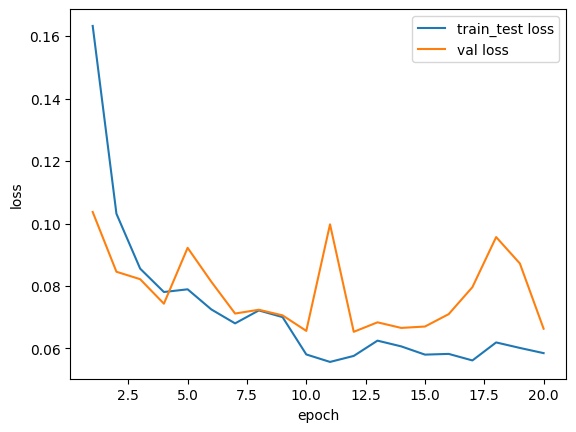

In [37]:
plt.plot([x+1 for x in range(len(all_train_loss))], np.array(all_train_loss), label="train_test loss")
plt.plot([x+1 for x in range(len(all_test_loss))], np.array(all_test_loss), label="val loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [10]:
# plt.plot([x+1 for x in range(len(all_lr))], all_lr, label="lr")
# plt.ylabel("learning rate")
# plt.xlabel("epoch")
# plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000106426676..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


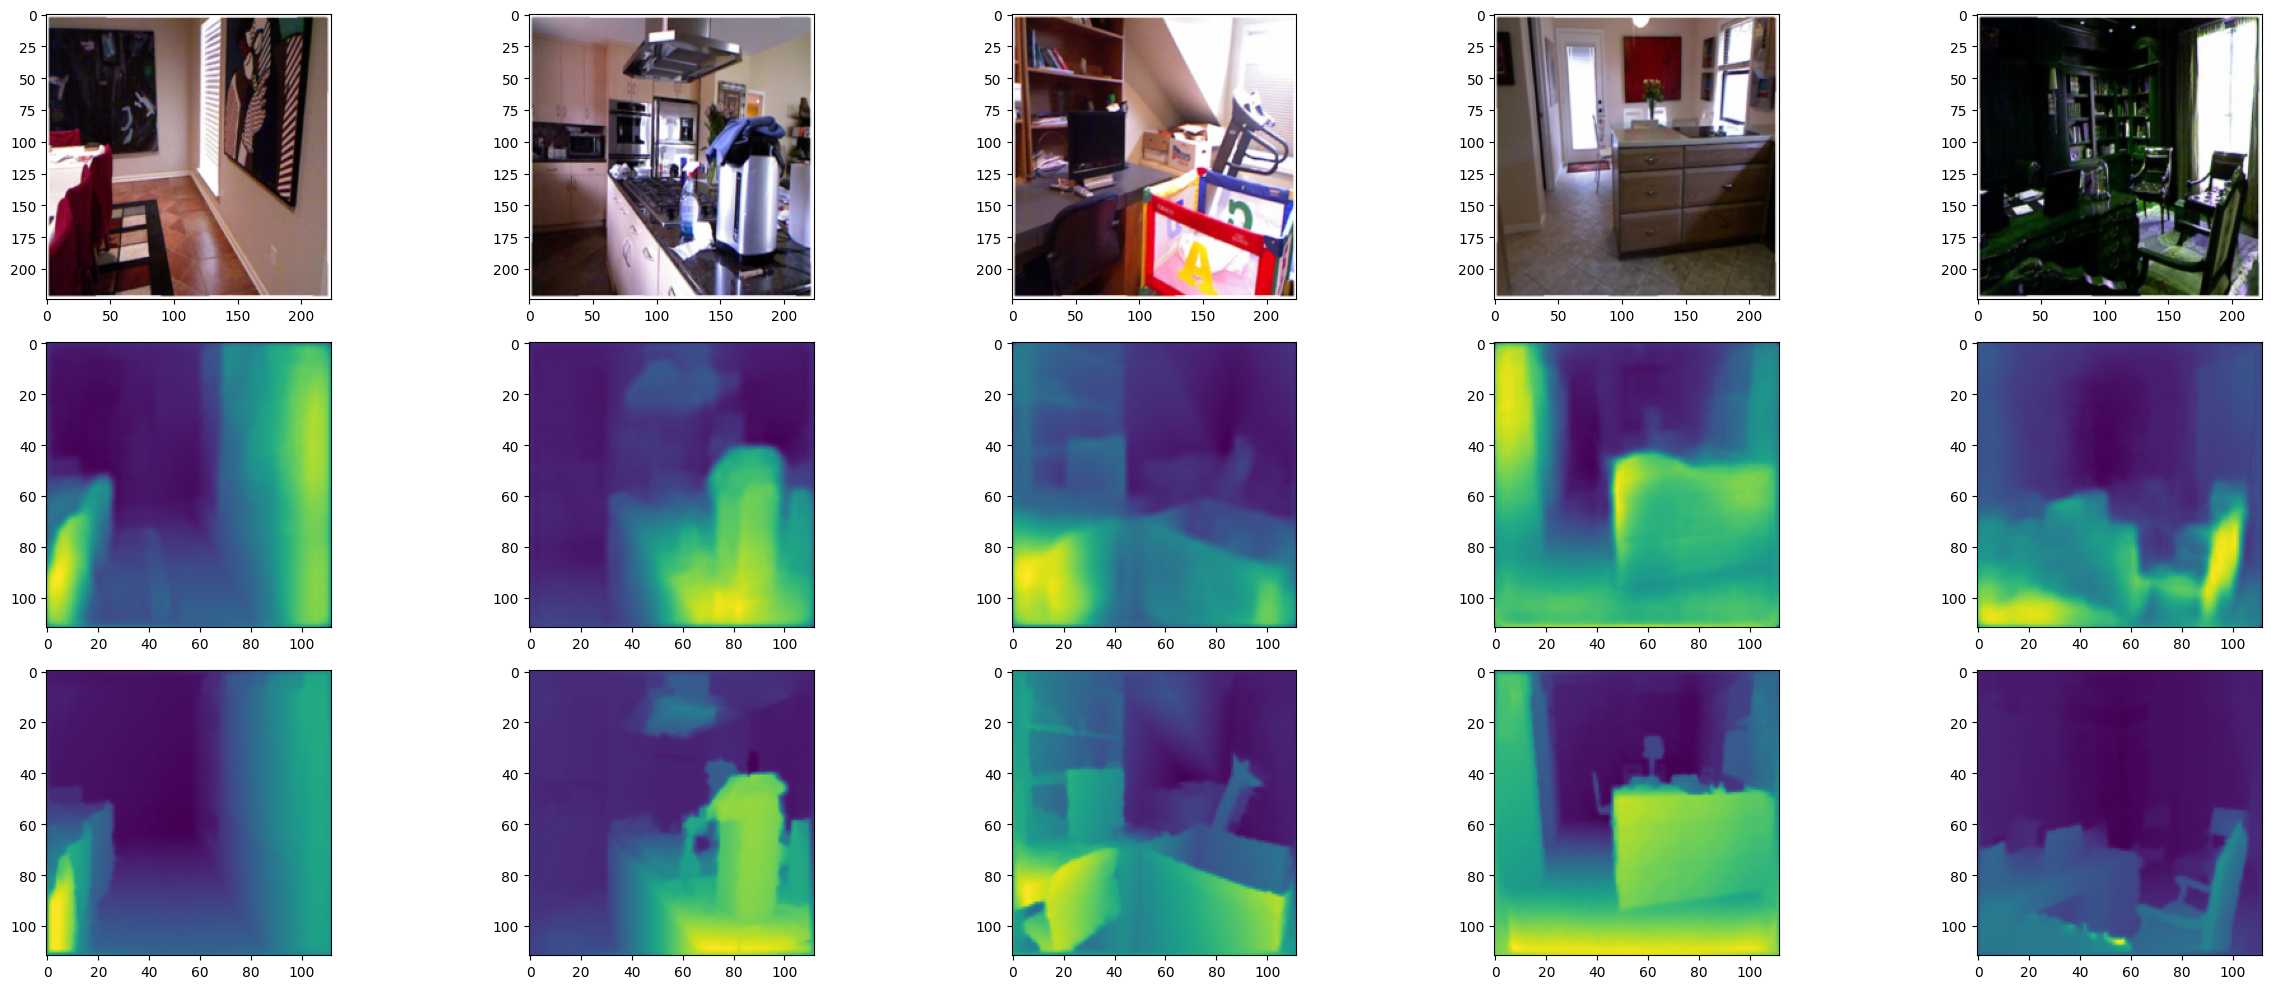

In [38]:
with torch.no_grad():
    model.eval()

    N = 5

    fig, axs = plt.subplots(3, N, figsize=(5*N, 10))

    i = 0
    for img, lbl in train_test_visualizer:
        img, lbl = img.to(DEVICE), lbl.to(DEVICE)

        # lbl = 1.0 / lbl
        
        pred = model(img)

        img = img[0]
        pred = pred[0]
        lbl = lbl[0]

        axs[0, i].imshow(img.cpu().permute(1, 2, 0))
        axs[1, i].imshow(pred.cpu().permute(1, 2, 0))
        axs[2, i].imshow(lbl.cpu().permute(1, 2, 0))

        i += 1
        if i == 5:
            break

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.772364e-05..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0009954417..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.6890706e-05..1.0000002].


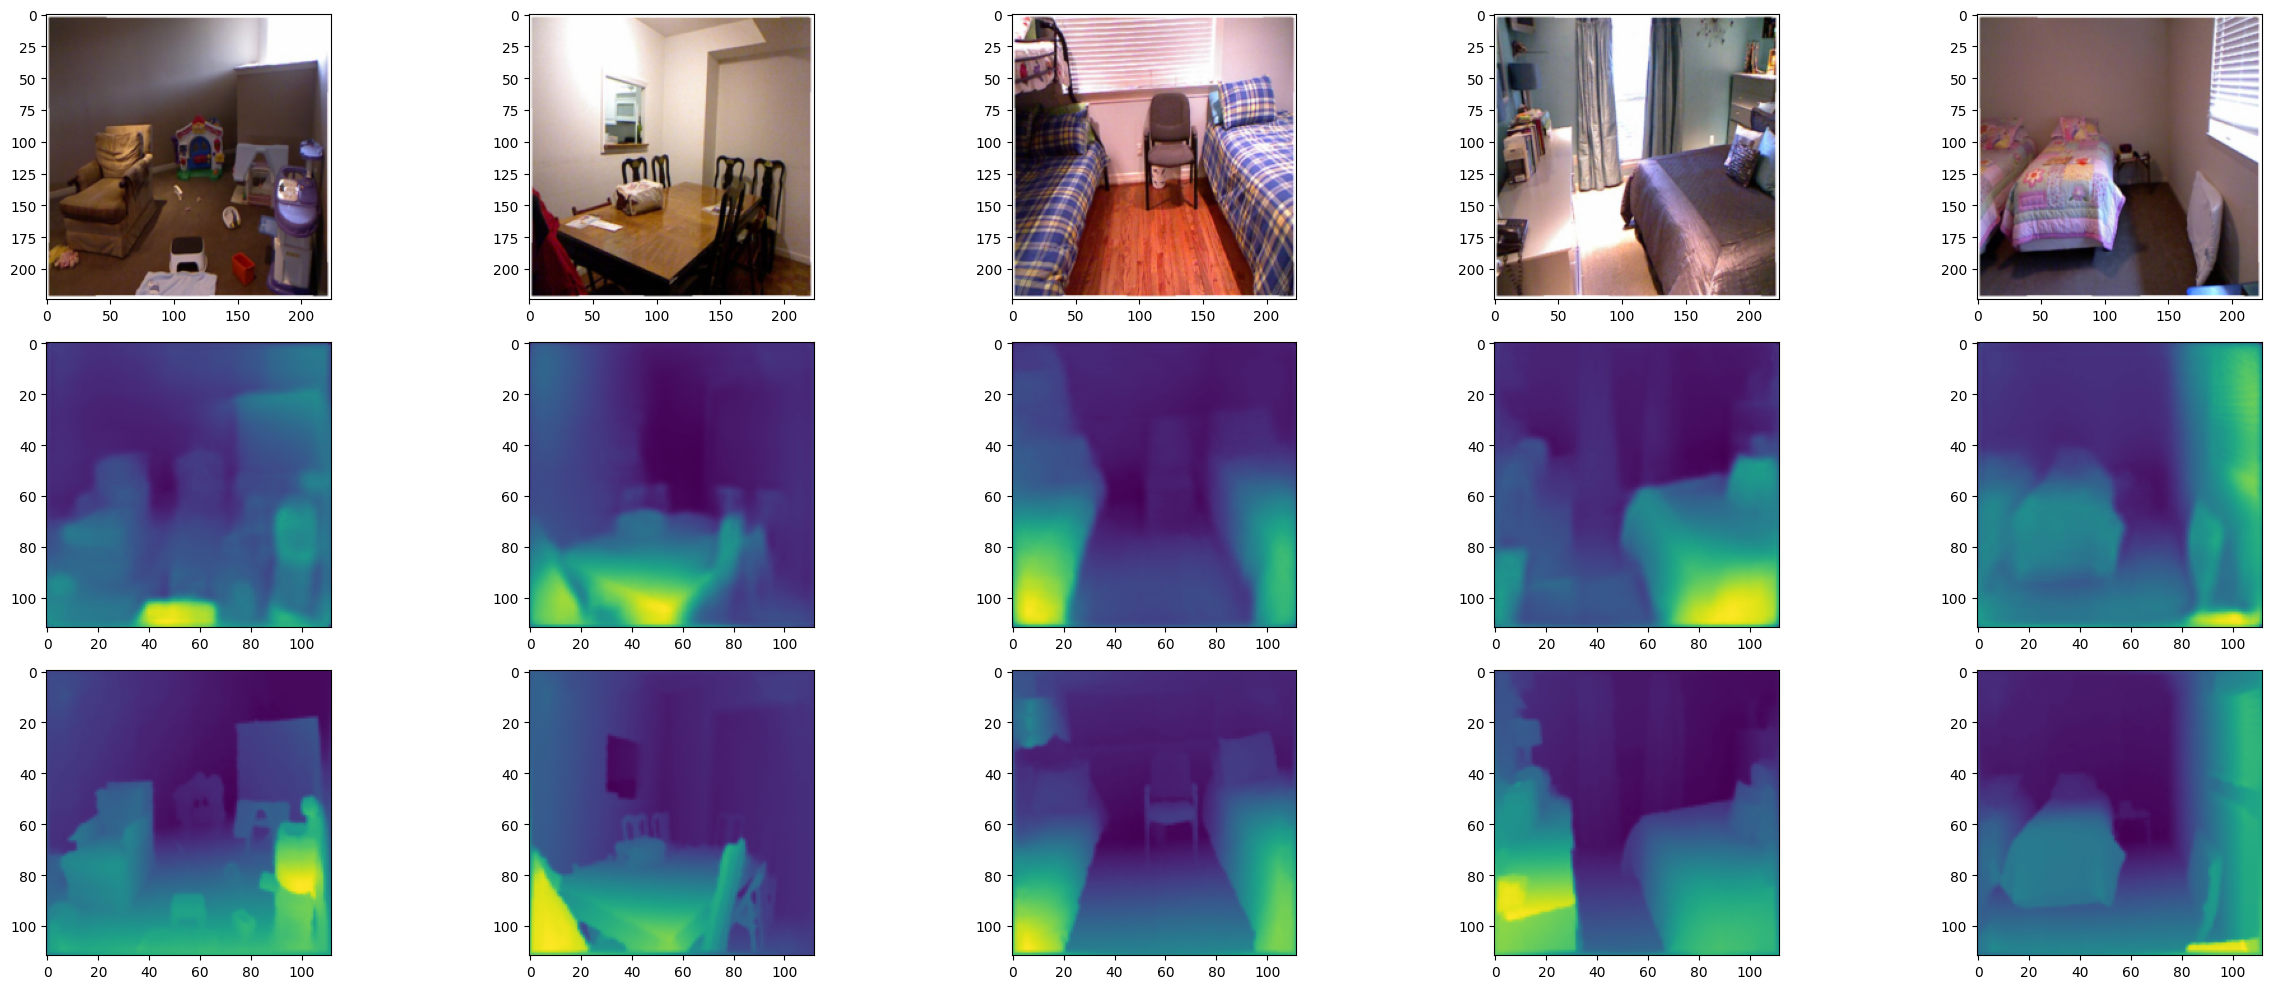

In [39]:
with torch.no_grad():
    model.eval()

    N = 5

    fig, axs = plt.subplots(3, N, figsize=(5*N, 10))

    i = 0
    for img, lbl in val_visualizer:
        img, lbl = img.to(DEVICE), lbl.to(DEVICE)

        # lbl = 1000.0 / lbl
        pred = model(img)

        img = img[0]
        pred = pred[0]
        lbl = lbl[0]

        axs[0, i].imshow(img.cpu().permute(1, 2, 0))
        axs[1, i].imshow(pred.cpu().permute(1, 2, 0))
        axs[2, i].imshow(lbl.cpu().permute(1, 2, 0))

        i += 1
        if i == 5:
            break

    plt.tight_layout()
    plt.show()

In [40]:
model.eval()

total_test_loss = 0
total_rel = 0
total_rmse = 0
total_ale = 0
total_epi = 0
total_f1 = 0

num_of_images = 0

for img, lbl in tqdm(val_dataloader):
    with torch.no_grad():

        img, lbl = img.to(DEVICE), lbl.to(DEVICE)

        pred = model(img)

        loss = Loss_fn(
            pred, lbl,
            depth=depth_coeficient,
            struct=struct_coeficient,
            grad=grad_coeficient,
            laplacian=laplacian_coeficient,
            scharr=scharr_coeficient
        )
        total_test_loss += loss.item()

        total_rel += functions.mean_relative_error(pred, lbl)
        total_rmse += functions.root_mean_squared_error(pred, lbl)
        total_ale += functions.average_log_error(pred, lbl)
        total_epi += functions.edge_preservation_index(pred, lbl)
        
        pred_f = pred.detach().cpu().numpy()
        lbl_f = lbl.detach().cpu().numpy()

        for p, l in zip(pred_f, lbl_f):
            num_of_images += 1
            total_f1 += functions.SI_boundary_F1(p.squeeze(), l.squeeze())


avg_test_loss = total_test_loss / len(test_dataloader)
print("test_loss:", avg_test_loss)

avg_rel = total_rel / len(val_dataloader)
print("avg_rel:", avg_rel)

avg_rmse = total_rmse / len(val_dataloader)
print("avg_rmse:", avg_rmse)

avg_ale = total_ale / len(val_dataloader)
print("avg_ale:", avg_ale)

avg_epi = total_epi / len(val_dataloader)
print("avg_epi:", avg_epi.item())

avg_f1 = total_f1 / num_of_images
print("avg_f1:", avg_f1)

  0%|          | 0/21 [00:00<?, ?it/s]

test_loss: 0.06631562415333021
avg_rel: 0.39229006
avg_rmse: 0.094631515
avg_ale: 0.273511
avg_epi: 0.9206162691116333
avg_f1: 0.2078203327513046


In [33]:
torch.save(model.state_dict(), r"Swin-DepthEstimatorV15.pt")

In [34]:
!ls

CustomDataset.py			     optuna_trial_15_pretty_good.pt
CustomLoss.py				     __pycache__
last_best_model_normalized_inverse_depth.pt  README.md
Models					     swin-CNN.pt
notebook.ipynb				     Swin-DepthEstimatorV15.pt
nyu_depth_v2_labeled.mat		     Utils


In [26]:
# model.load_state_dict(torch.load("swin-CNN.pt"))

<All keys matched successfully>

In [21]:
_ = '''
# no-laplace:
test_loss: 0.0753559182990681
avg_rel: 0.3208493
avg_rmse: 0.1174444
avg_ale: 0.31526098

# with laplace:
test_loss: 0.10680215236815539
avg_rel: 0.33336896
avg_rmse: 0.112621404
avg_ale: 0.2918413

# laplace 20 epochs
test_loss: 0.10260066904804924
avg_rel: 0.3007515
avg_rmse: 0.10764205
avg_ale: 0.2860509

test_loss: 0.1136012768020501
avg_rel: 0.32884717
avg_rmse: 0.12679999
avg_ale: 0.32673237

# with big beefy loss
test_loss: 0.41884947299957276
avg_rel: 1.0194693
avg_rmse: 0.13445286
avg_ale: 0.44593143

# depois do optuna 20 epocas
test_loss: 0.07262067556381226
avg_rel: 0.45411482
avg_rmse: 0.10201665
avg_ale: 0.28180835
avg_epi: 0.8928451538085938

# sem upscale 56x56
test_loss: 0.11178722083568574
avg_rel: 0.40899348
avg_rmse: 0.09330484
avg_ale: 0.26239377
avg_epi: 0.9252623319625854

# com a ultima skip connection sem upscale 56x56
test_loss: 0.11943498849868775
avg_rel: 0.4051135
avg_rmse: 0.09803958
avg_ale: 0.27906454
avg_epi: 0.9256203174591064

# com a ultima skip connection upscale 224x224
test_loss: 0.08038171261548996
avg_rel: 0.6929972
avg_rmse: 0.106820315
avg_ale: 0.31946728
avg_epi: 0.8830851316452026

# com a ultima skip connection upscale 112x112
test_loss: 0.09699111312627792
avg_rel: 0.67044884
avg_rmse: 0.103319846
avg_ale: 0.31280524
avg_epi: 0.8977692723274231

# nearest 5 epocas
test_loss: 0.09366959810256958
avg_rel: 0.586922
avg_rmse: 0.0992336
avg_ale: 0.29119977
avg_epi: 0.9031897783279419

# bicubic 5 epocas
test_loss: 0.0970400008559227
avg_rel: 0.60159296
avg_rmse: 0.11164812
avg_ale: 0.31008205
avg_epi: 0.8961054682731628

test_loss: 0.10970972388982773
avg_rel: 0.54490846
avg_rmse: 0.1250012
avg_ale: 0.37272424
avg_epi: 0.8974670767784119

# 20 epocas 112x112 nearest
test_loss: 0.10823288381099701
avg_rel: 0.5372953
avg_rmse: 0.1299798
avg_ale: 0.36110592
avg_epi: 0.9090388417243958

# Swin DE V15
test_loss: 0.05129800080543473
avg_rel: 0.33833948
avg_rmse: 0.09737774
avg_ale: 0.31808284
avg_epi: 0.9107245802879333
avg_f1: 0.2569966407623174

# 1
Trial 1 - values: [1.0481125116348267, 0.13513034582138062, 0.4218918979167938, 0.870063066482544], params: {'depth_coeficient': 6.841298116466118e-05, 'struct_coeficient': 0.03248325092772515, 'grad_coeficient': 0.0051424867407542, 'laplacian_coeficient': 3.00554615340988e-06, 'scharr_coeficient': 0.00488205481613278}
Trial 2 - values: [0.9571280479431152, 0.11994954943656921, 0.3765481412410736, 0.8310078978538513], params: {'depth_coeficient': 0.32903503264710193, 'struct_coeficient': 6.163135237878189e-06, 'grad_coeficient': 3.467355248299266e-06, 'laplacian_coeficient': 0.0003629959803895591, 'scharr_coeficient': 6.28975138352269e-06}
Trial 3 - values: [0.9955368041992188, 0.13679669797420502, 0.40928179025650024, 0.8594187498092651], params: {'depth_coeficient': 4.893959344546544e-05, 'struct_coeficient': 0.1884006961400663, 'grad_coeficient': 0.0028072487734431433, 'laplacian_coeficient': 0.0008369340337708978, 'scharr_coeficient': 3.844321393087618e-06}

# 2
Trial 8 - values: [0.7161348462104797, 0.12937764823436737, 0.38180553913116455, 0.8646581768989563], params: {'depth_coeficient': 0.026477005940685455, 'struct_coeficient': 0.0018305715746969415, 'grad_coeficient': 0.010264130898595071, 'laplacian_coeficient': 2.9090948992140066e-05, 'scharr_coeficient': 1.1978090863076018e-05}
Trial 10 - values: [0.9386582970619202, 0.13207672536373138, 0.4326324760913849, 0.8665140867233276], params: {'depth_coeficient': 0.20417141185911133, 'struct_coeficient': 0.09879927510187045, 'grad_coeficient': 2.3138206185441263e-05, 'laplacian_coeficient': 0.0030843831721023072, 'scharr_coeficient': 0.030991822783788554}
Trial 15 - values: [0.8629385232925415, 0.13789120316505432, 0.4355769455432892, 0.8651773929595947], params: {'depth_coeficient': 0.00016771005064552654, 'struct_coeficient': 0.000652264647870426, 'grad_coeficient': 3.186582819655759e-06, 'laplacian_coeficient': 0.00012566145352677405, 'scharr_coeficient': 4.469873496396284e-06}
Trial 21 - values: [0.7141006588935852, 0.10853882879018784, 0.33623847365379333, 0.8629375100135803], params: {'depth_coeficient': 0.7002882173479286, 'struct_coeficient': 9.052385618746442e-06, 'grad_coeficient': 2.1747446466583166e-06, 'laplacian_coeficient': 0.04320903120397826, 'scharr_coeficient': 0.009002220537478036}
Trial 23 - values: [0.6339265704154968, 0.11920759081840515, 0.37400731444358826, 0.7920421361923218], params: {'depth_coeficient': 0.4417575893947489, 'struct_coeficient': 2.5459716236553663e-06, 'grad_coeficient': 0.0031459684230776175, 'laplacian_coeficient': 0.00017116032382956503, 'scharr_coeficient': 0.0015063824095965812}



# mega optuna
Trial 6 - values: [0.9819514155387878, 0.1313541680574417, 0.4296180307865143, 0.8799827098846436, 0.053968401174166014], params: {'depth_coeficient': np.float64(0.09795963090878099), 'struct_coeficient': np.float64(0.3477142020260543), 'grad_coeficient': np.float64(0.5371375959781662), 'laplacian_coeficient': np.float64(0.010313806591092689), 'scharr_coeficient': np.float64(0.0068747644959058826)}
Trial 13 - values: [0.9466618895530701, 0.13251128792762756, 0.43362122774124146, 0.8786059021949768, 0.04351444233991344], params: {'depth_coeficient': np.float64(0.08073515612455806), 'struct_coeficient': np.float64(0.37053464805928604), 'grad_coeficient': np.float64(0.5315642012825357), 'laplacian_coeficient': np.float64(0.016085468558994655), 'scharr_coeficient': np.float64(0.0010805259746254636)}
Trial 15 - values: [0.795099139213562, 0.12485086172819138, 0.38771361112594604, 0.8761641383171082, 0.05667318380773502], params: {'depth_coeficient': np.float64(0.15283395940623482), 'struct_coeficient': np.float64(0.5191248310600005), 'grad_coeficient': np.float64(0.3280412095337647), 'laplacian_coeficient': np.float64(-0.0), 'scharr_coeficient': np.float64(-0.0)}
Trial 16 - values: [0.9556124806404114, 0.13120512664318085, 0.42866307497024536, 0.8758915662765503, 0.060642872717467364], params: {'depth_coeficient': np.float64(0.1497486965547822), 'struct_coeficient': np.float64(0.5967045102491325), 'grad_coeficient': np.float64(0.2535467931960853), 'laplacian_coeficient': np.float64(-0.0), 'scharr_coeficient': np.float64(-0.0)}
Trial 22 - values: [0.8912960290908813, 0.12955538928508759, 0.4199671447277069, 0.8659147024154663, 0.05827713860076384], params: {'depth_coeficient': np.float64(0.9307914818837058), 'struct_coeficient': np.float64(0.06920851811629418), 'grad_coeficient': np.float64(-0.0), 'laplacian_coeficient': np.float64(-0.0), 'scharr_coeficient': np.float64(-0.0)}
Trial 24 - values: [1.0401301383972168, 0.1295926570892334, 0.44226089119911194, 0.8683523535728455, 0.060782611552327705], params: {'depth_coeficient': np.float64(0.8531077410392066), 'struct_coeficient': np.float64(0.14689225896079341), 'grad_coeficient': np.float64(-0.0), 'laplacian_coeficient': np.float64(-0.0), 'scharr_coeficient': np.float64(-0.0)}
Trial 25 - values: [0.9631625413894653, 0.132220059633255, 0.426104873418808, 0.8665816187858582, 0.07134477483617989], params: {'depth_coeficient': np.float64(0.34676206125939774), 'struct_coeficient': np.float64(0.6532379387406022), 'grad_coeficient': np.float64(-0.0), 'laplacian_coeficient': np.float64(-0.0), 'scharr_coeficient': np.float64(-0.0)}
Trial 26 - values: [1.0048729181289673, 0.13085472583770752, 0.43545281887054443, 0.8607257604598999, 0.06522162771758312], params: {'depth_coeficient': np.float64(0.26232078129532743), 'struct_coeficient': np.float64(0.7376792187046725), 'grad_coeficient': np.float64(-0.0), 'laplacian_coeficient': np.float64(5.722211415922275e-17), 'scharr_coeficient': np.float64(5.722211415922275e-17)}
Trial 28 - values: [0.9507129192352295, 0.13318824768066406, 0.43162035942077637, 0.8692262172698975, 0.06638389358163857], params: {'depth_coeficient': np.float64(-0.0), 'struct_coeficient': np.float64(1.0), 'grad_coeficient': np.float64(-0.0), 'laplacian_coeficient': np.float64(-0.0), 'scharr_coeficient': np.float64(-0.0)}
Trial 29 - values: [0.7386220693588257, 0.13189376890659332, 0.4055539667606354, 0.8534247279167175, 0.05448960748883842], params: {'depth_coeficient': np.float64(0.999999999999999), 'struct_coeficient': np.float64(-0.0), 'grad_coeficient': np.float64(5.110100260041161e-16), 'laplacian_coeficient': np.float64(5.110100260041161e-16), 'scharr_coeficient': np.float64(-0.0)}
'''